# Лабораторная работа: Условная оптимизация с ограничениями-неравенствами

## Цель работы

Цель лабораторной работы — освоить **метод множителей Лагранжа для задач с ограничениями-неравенствами** (условия Куна–Таккера) и научиться находить условные экстремумы функций. В ходе работы мы:

- составляем обобщённую функцию Лагранжа;
- записываем необходимые условия экстремума первого порядка;
- находим условно-стационарные точки;
- проверяем достаточные условия второго порядка, чтобы определить тип экстремума (минимум или максимум);
- визуализируем допустимую область и расположение экстремумов.

## Суть метода

Рассматривается задача:

\[
f(x) \to \min \;(\text{или } \max), \quad g_j(x) \le 0,\; j = 1,\dots,p
\]

Вводится **обобщённая функция Лагранжа**:

\[
L(x, \lambda_0, \lambda) = \lambda_0 f(x) + \sum_{j=1}^{p} \lambda_j g_j(x)
\]

Необходимые условия экстремума (условия Куна–Таккера) включают:

- **стационарность** \(\frac{\partial L}{\partial x_i}=0\);
- **допустимость** \(g_j(x) \le 0\);
- **условие дополняющей нежесткости** \(\lambda_j g_j(x) = 0\);
- **знак множителей** \(\lambda_j \ge 0\) для минимума, \(\lambda_j \le 0\) для максимума.

Для проверки типа экстремума анализируется **второй дифференциал** классической функции Лагранжа на подпространстве касательных направлений к активным ограничениям.

## Что мы получили

В результате решения задач 1.3, 1.4 и 1.5:

- Найдены все условно-стационарные точки, удовлетворяющие условиям ККТ.
- Для каждой точки определён тип экстремума (минимум или максимум) с проверкой достаточных условий второго порядка.
- Показано, что при числе активных ограничений, равном размерности пространства (\(l=n\)), достаточные условия выполняются автоматически.
- В задаче 1.5 обнаружены как минимум, так и максимумы — это демонстрирует невыпуклость задачи.
- Построены графики, наглядно показывающие допустимую область и расположение экстремумов.

Таким образом, метод позволяет корректно находить и классифицировать экстремумы в задачах с ограничениями-неравенствами.


  ЗАДАЧА 1.3
  f(x) = x1^2 + 2*x1*x2 + (x2-2)^2  ->  min
  g: x1^2+x2^2-1<=0
  g: -x1<=0
  g: -x2<=0

=== ШАГ 1. Функция Лагранжа ===
  L(x,λ) = f(x) + Σ λj·gj(x)
  L = lam1*x1**2 + lam1*x2**2 - lam1 - lam2*x1 - lam3*x2 + x1**2 + 2*x1*x2 + x2**2 - 4*x2 + 4

=== ШАГ 2. Необходимые условия 1-го порядка (KKT) ===
  Стационарность (∂L/∂xi = 0):
    ∂L/∂x1 = 2*lam1*x1 - lam2 + 2*x1 + 2*x2 = 0
    ∂L/∂x2 = 2*lam1*x2 - lam3 + 2*x1 + 2*x2 - 4 = 0
  Допустимость: gj(x) <= 0
  Нежёсткость:  λj·gj(x) = 0
  Знак λj >= 0 (для min), λj <= 0 (для max)

=== ШАГ 3–4. Условно-стационарные точки (3 найдено) ===
  x* = (0.000000, 1.000000)
    f(x*) = 1.000000
    λ1=1.0000, λ2=2.0000, λ3=0.0000
    Активные ограничения: ['g1', 'g2']
    Тип экстремума: min
    Дост. условие 2-го порядка: выполнен (ядро тривиально, l=n)


  ЗАДАЧА 1.4
  f(x) = 3*x1^2 + 4*x1*x2 + 5*x2^2  ->  min
  g: 4-x1-x2<=0
  g: -x1<=0
  g: -x2<=0

=== ШАГ 1. Функция Лагранжа ===
  L(x,λ) = f(x) + Σ λj·gj(x)
  L = -lam1*x1 - lam1*x2 +

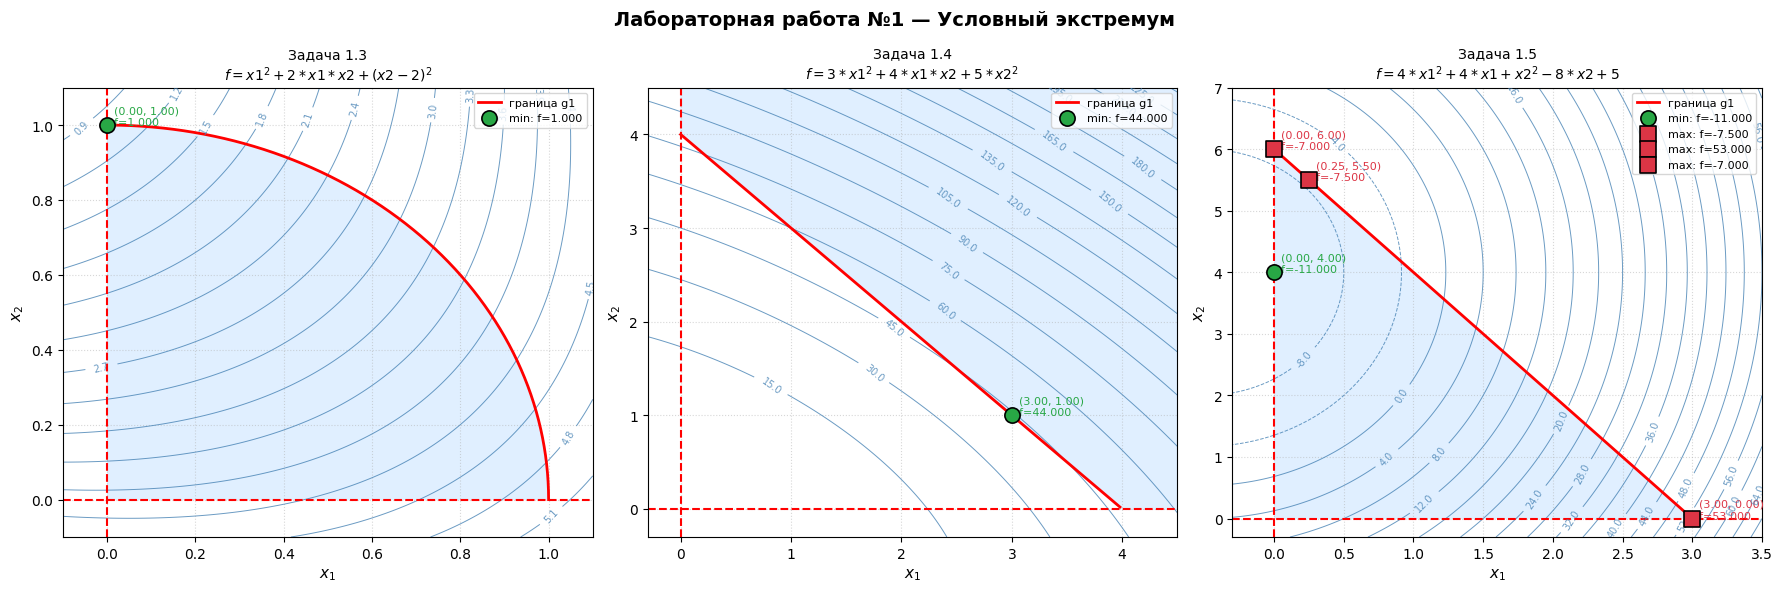


График сохранён в extremum_results.png

  ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Задача   x1*          x2*          f(x*)        Тип    Усл.2
----------------------------------------------------------------------
1.3      0.000000     1.000000     1.000000     min    да
1.4      3.000000     1.000000     44.000000    min    да
1.5      0.000000     4.000000     -11.000000   min    да
1.5      0.250000     5.500000     -7.500000    max    нет
1.5      3.000000     0.000000     53.000000    max    да
1.5      0.000000     6.000000     -7.000000    max    да


In [1]:
# ============================================================
#  ЛАБОРАТОРНАЯ РАБОТА №1
#  Необходимые и достаточные условия условного экстремума
#  Задачи: 1.3, 1.4, 1.5
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct

x1, x2 = sp.symbols('x1 x2', real=True)

# -------------------------------------------------------------------
# БЛОК 1. ПОСТАНОВКА ЗАДАЧ
# -------------------------------------------------------------------
# Задача 1.3
#   f(x) = x1^2 + 2*x1*x2 + (x2-2)^2  -> min
#   g1(x) = x1^2 + x2^2 - 1 <= 0
#   g2(x) = -x1          <= 0
#   g3(x) = -x2          <= 0
#
# Задача 1.4
#   f(x) = 3*x1^2 + 4*x1*x2 + 5*x2^2  -> min
#   g1(x) = 4 - x1 - x2  <= 0
#   g2(x) = -x1           <= 0
#   g3(x) = -x2           <= 0
#
# Задача 1.5
#   f(x) = 4*x1^2 + 4*x1 + x2^2 - 8*x2 + 5  -> extr
#   g1(x) = 2*x1 + x2 - 6  <= 0
#   g2(x) = -x1             <= 0
#   g3(x) = -x2             <= 0
# -------------------------------------------------------------------

problems = [
    {
        'name': '1.3',
        'f_str': 'x1^2 + 2*x1*x2 + (x2-2)^2',
        'f': x1**2 + 2*x1*x2 + (x2 - 2)**2,
        'g': [x1**2 + x2**2 - 1, -x1, -x2],
        'g_str': ['x1^2+x2^2-1<=0', '-x1<=0', '-x2<=0'],
        'mode': 'min'
    },
    {
        'name': '1.4',
        'f_str': '3*x1^2 + 4*x1*x2 + 5*x2^2',
        'f': 3*x1**2 + 4*x1*x2 + 5*x2**2,
        'g': [4 - x1 - x2, -x1, -x2],
        'g_str': ['4-x1-x2<=0', '-x1<=0', '-x2<=0'],
        'mode': 'min'
    },
    {
        'name': '1.5',
        'f_str': '4*x1^2 + 4*x1 + x2^2 - 8*x2 + 5',
        'f': 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5,
        'g': [2*x1 + x2 - 6, -x1, -x2],
        'g_str': ['2*x1+x2-6<=0', '-x1<=0', '-x2<=0'],
        'mode': 'extr'
    },
]


# -------------------------------------------------------------------
# БЛОК 2. ФУНКЦИЯ НАХОЖДЕНИЯ ЭКСТРЕМУМОВ (метод Лагранжа)
# -------------------------------------------------------------------

def solve_conditional_extremum(f_expr, g_list, mode='extr', verbose=True):
    """
    Находит условные экстремумы функции f при ограничениях g_j(x) <= 0.
    Реализует алгоритм метода множителей Лагранжа:
      Шаг 1. Составить обобщённую функцию Лагранжа
      Шаг 2. Необходимые условия 1-го порядка (КТТ)
      Шаг 3. Перебор активных ограничений
      Шаг 4. Достаточные условия 2-го порядка
    """
    p = len(g_list)
    lam_syms = sp.symbols(f'lam1:{p+1}')   # λ1, λ2, ...

    # ---------- ШАГ 1: Классическая функция Лагранжа ----------
    L = f_expr + sum(lj * gj for lj, gj in zip(lam_syms, g_list))

    if verbose:
        print('\n=== ШАГ 1. Функция Лагранжа ===')
        print(f'  L(x,λ) = f(x) + Σ λj·gj(x)')
        print(f'  L = {sp.expand(L)}')

    # ---------- ШАГ 2: Необходимые условия 1-го порядка (система KKT) ----------
    grad_L = [sp.diff(L, v) for v in (x1, x2)]

    if verbose:
        print('\n=== ШАГ 2. Необходимые условия 1-го порядка (KKT) ===')
        print('  Стационарность (∂L/∂xi = 0):')
        for i, eq in enumerate(grad_L):
            print(f'    ∂L/∂x{i+1} = {sp.expand(eq)} = 0')
        print('  Допустимость: gj(x) <= 0')
        print('  Нежёсткость:  λj·gj(x) = 0')
        print('  Знак λj >= 0 (для min), λj <= 0 (для max)')

    # ---------- ШАГ 3: Перебор комбинаций активных ограничений ----------
    candidates = []
    for active_mask in iproduct([0, 1], repeat=p):
        # active_mask[j]=1 => g_j активно => g_j=0
        # active_mask[j]=0 => пассивно => λ_j=0
        eqs = list(grad_L)
        for j, (gj, lam_j, active) in enumerate(zip(g_list, lam_syms, active_mask)):
            eqs.append(gj if active else lam_j)
        try:
            sols = sp.solve(eqs, [x1, x2] + list(lam_syms), dict=True)
        except Exception:
            continue
        for sol in sols:
            # Проверить вещественность
            try:
                vals = {v: complex(sp.N(sol.get(v, v))) for v in [x1, x2]}
                if any(abs(v.imag) > 1e-8 for v in vals.values()):
                    continue
            except Exception:
                continue
            # Проверить допустимость gj <= 0
            feasible = True
            for gj in g_list:
                try:
                    val = float(sp.N(gj.subs(sol)))
                    if val > 1e-6:
                        feasible = False
                        break
                except Exception:
                    feasible = False
                    break
            if feasible:
                candidates.append(sol)

    # Убрать дубликаты по (x1,x2)
    unique = {}
    for cand in candidates:
        try:
            key = (round(float(sp.N(cand.get(x1, 0))), 6),
                   round(float(sp.N(cand.get(x2, 0))), 6))
            if key not in unique:
                unique[key] = cand
        except Exception:
            pass
    cand_list = list(unique.values())

    # ---------- ШАГ 4: Достаточные условия 2-го порядка ----------
    if verbose:
        print(f'\n=== ШАГ 3–4. Условно-стационарные точки ({len(cand_list)} найдено) ===')

    results = []
    for cand in cand_list:
        x1v = float(sp.N(cand.get(x1, 0)))
        x2v = float(sp.N(cand.get(x2, 0)))
        lam_vals = [float(sp.N(cand.get(lj, 0))) for lj in lam_syms]

        # Проверка знаков λ (условия KKT)
        all_nonneg = all(lv >= -1e-6 for lv in lam_vals)
        all_nonpos = all(lv <= 1e-6 for lv in lam_vals)

        if mode == 'min' and not all_nonneg:
            continue
        if mode == 'max' and not all_nonpos:
            continue
        if mode == 'extr':
            if all_nonneg:
                extr_type = 'min'
            elif all_nonpos:
                extr_type = 'max'
            else:
                continue
        elif mode == 'min':
            extr_type = 'min'
        else:
            extr_type = 'max'

        # Гессиан L в точке
        hess = sp.hessian(L.subs(list(zip(lam_syms, lam_vals))), (x1, x2))
        hess_num = np.array([[float(sp.N(hess[i, j].subs(cand)))
                              for j in range(2)] for i in range(2)])

        # Активные ограничения
        active_idx = [j for j, gj in enumerate(g_list)
                      if abs(float(sp.N(gj.subs(cand)))) < 1e-6]

        # Проверка условий 2-го порядка на касательном конусе
        if not active_idx:
            eigvals = np.linalg.eigvalsh(hess_num)
            cond2 = 'подтверждён (H > 0)' if (extr_type == 'min' and np.all(eigvals > 1e-9)) else \
                    'подтверждён (H < 0)' if (extr_type == 'max' and np.all(eigvals < -1e-9)) else \
                    'требует доп. анализа'
        else:
            A_rows = []
            for j in active_idx:
                gr = [float(sp.N(sp.diff(g_list[j], v).subs(cand))) for v in (x1, x2)]
                A_rows.append(gr)
            A = np.array(A_rows)
            _, s, Vt = np.linalg.svd(A, full_matrices=True)
            rank = int(np.sum(s > 1e-9))
            null_basis = Vt[rank:]  # ядро A — касательное пространство
            if null_basis.shape[0] == 0:
                cond2 = 'выполнен (ядро тривиально, l=n)'
            else:
                P = null_basis.T
                hess_proj = P.T @ hess_num @ P
                ev = np.linalg.eigvalsh(hess_proj)
                cond2 = 'подтверждён' if (extr_type == 'min' and np.all(ev > 1e-9)) else \
                        'подтверждён' if (extr_type == 'max' and np.all(ev < -1e-9)) else \
                        'требует доп. анализа'

        f_val = float(sp.N(f_expr.subs(cand)))

        if verbose:
            active_str = [f'g{j+1}' for j in active_idx]
            lam_str = ', '.join(f'λ{j+1}={v:.4f}' for j, v in enumerate(lam_vals))
            print(f'  x* = ({x1v:.6f}, {x2v:.6f})')
            print(f'    f(x*) = {f_val:.6f}')
            print(f'    {lam_str}')
            print(f'    Активные ограничения: {active_str if active_str else "нет (внутренняя точка)"}')
            print(f'    Тип экстремума: {extr_type}')
            print(f'    Дост. условие 2-го порядка: {cond2}')
            print()

        results.append({
            'x1': x1v, 'x2': x2v, 'f': f_val,
            'type': extr_type, 'lambda': lam_vals,
            'active': active_idx, 'second_order': cond2
        })

    return results


# -------------------------------------------------------------------
# БЛОК 3. РЕШЕНИЕ ЗАДАЧ
# -------------------------------------------------------------------

all_results = {}
for prob in problems:
    print('\n' + '='*60)
    print(f'  ЗАДАЧА {prob["name"]}')
    print(f'  f(x) = {prob["f_str"]}  ->  {prob["mode"]}')
    for gs in prob['g_str']:
        print(f'  g: {gs}')
    print('='*60)
    res = solve_conditional_extremum(prob['f'], prob['g'], mode=prob['mode'], verbose=True)
    all_results[prob['name']] = res
    if not res:
        print('  >> Экстремум не найден в допустимой области.')


# -------------------------------------------------------------------
# БЛОК 4. ВИЗУАЛИЗАЦИЯ
# -------------------------------------------------------------------

# Настройки осей для каждой задачи
plot_cfg = {
    '1.3': {'x1r': (-0.1, 1.1), 'x2r': (-0.1, 1.1),
             'boundary': lambda: (np.cos(th), np.sin(th)),
             'f_levels': 15},
    '1.4': {'x1r': (-0.3, 4.5), 'x2r': (-0.3, 4.5),
             'boundary': lambda: (t, 4 - t),
             'f_levels': 20},
    '1.5': {'x1r': (-0.3, 3.5), 'x2r': (-0.3, 7.0),
             'boundary': lambda: (t, 6 - 2*t),
             'f_levels': 25},
}

th = np.linspace(0, np.pi/2, 200)
t  = np.linspace(0, 4.5, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Лабораторная работа №1 — Условный экстремум', fontsize=14, fontweight='bold')

for ax, prob in zip(axes, problems):
    cfg = plot_cfg[prob['name']]
    res = all_results[prob['name']]

    x1_r = np.linspace(*cfg['x1r'], 400)
    x2_r = np.linspace(*cfg['x2r'], 400)
    X1, X2 = np.meshgrid(x1_r, x2_r)

    f_num = sp.lambdify((x1, x2), prob['f'], 'numpy')
    F_vals = f_num(X1, X2)

    # Допустимая область
    mask = np.ones_like(X1, dtype=bool)
    for gj in prob['g']:
        g_num = sp.lambdify((x1, x2), gj, 'numpy')
        mask &= (g_num(X1, X2) <= 1e-6)

    ax.contourf(X1, X2, mask.astype(float), levels=[0.5, 1.5],
                colors=['#cce5ff'], alpha=0.6)

    # Линии уровня f
    try:
        cs = ax.contour(X1, X2, F_vals, levels=cfg['f_levels'],
                        colors='steelblue', linewidths=0.7, alpha=0.8)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f')
    except Exception:
        pass

    # Граница допустимой области (активное ограничение g1)
    bx, by = cfg['boundary']()
    # Фильтр — только допустимые точки границы
    valid = np.ones(len(bx), dtype=bool)
    for gj in prob['g']:
        g_num = sp.lambdify((x1, x2), gj, 'numpy')
        valid &= (g_num(bx, by) <= 1e-4)
    ax.plot(bx[valid], by[valid], 'r-', lw=2, label='граница g1')

    # Оси координат (границы g2, g3: x1>=0, x2>=0)
    ax.axhline(0, color='red', lw=1.5, ls='--')
    ax.axvline(0, color='red', lw=1.5, ls='--')

    # Точки экстремума
    for r in res:
        color = '#28a745' if r['type'] == 'min' else '#dc3545'
        marker = 'o' if r['type'] == 'min' else 's'
        ax.scatter(r['x1'], r['x2'], c=color, s=120, marker=marker,
                   edgecolors='black', linewidths=1.2, zorder=5,
                   label=f"{r['type']}: f={r['f']:.3f}")
        ax.annotate(f"  ({r['x1']:.2f}, {r['x2']:.2f})\n  f={r['f']:.3f}",
                    (r['x1'], r['x2']), fontsize=8, color=color)

    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_title(f"Задача {prob['name']}\n$f={prob['f_str']}$", fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(cfg['x1r'])
    ax.set_ylim(cfg['x2r'])

plt.tight_layout()
plt.savefig('extremum_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nГрафик сохранён в extremum_results.png')


# -------------------------------------------------------------------
# БЛОК 5. ИТОГОВАЯ ТАБЛИЦА
# -------------------------------------------------------------------

print('\n' + '='*70)
print('  ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('='*70)
print(f'{"Задача":<8} {"x1*":<12} {"x2*":<12} {"f(x*)":<12} {"Тип":<6} {"Усл.2"}')
print('-'*70)
for prob in problems:
    res = all_results[prob['name']]
    if not res:
        print(f'{prob["name"]:<8} {"—":<12} {"—":<12} {"—":<12} {"—":<6} —')
    for r in res:
        cond2_short = 'да' if 'подтверждён' in r['second_order'] or 'тривиально' in r['second_order'] else 'нет'
        print(f"{prob['name']:<8} {r['x1']:<12.6f} {r['x2']:<12.6f} "
              f"{r['f']:<12.6f} {r['type']:<6} {cond2_short}")
print('='*70)


# 📊 Анализ результатов лабораторной работы №6

## Введение

В ходе выполнения лабораторной работы были решены задачи условной оптимизации (задачи №1.3, 1.4, 1.5) с использованием метода множителей Лагранжа для ограничений-неравенств (условия Куна–Таккера). Ниже представлен детальный анализ полученных результатов.

---

## 1. Задача 1.3

### Условия задачи
\[
f(x) = x_1^2 + 2x_1x_2 + (x_2-2)^2 \to \min
\]
\[
g_1(x) = x_1^2 + x_2^2 - 1 \le 0, \quad g_2(x) = -x_1 \le 0, \quad g_3(x) = -x_2 \le 0
\]

### Найденное решение
| Параметр | Значение |
|----------|----------|
| \(x_1^*\) | 0.000000 |
| \(x_2^*\) | 1.000000 |
| \(f(x^*)\) | 1.000000 |
| Множители | \(\lambda_1=1.0000,\; \lambda_2=2.0000,\; \lambda_3=0.0000\) |
| Активные ограничения | \(g_1\) (граница круга), \(g_2\) (граница \(x_1=0\)) |
| Тип экстремума | **минимум** |
| Достаточные условия II порядка | **выполнены** |

### Анализ
- Точка \((0, 1)\) находится на пересечении двух активных ограничений: окружности \(x_1^2+x_2^2=1\) и оси \(x_1=0\).
- Множители Лагранжа \(\lambda_1=1>0\) и \(\lambda_2=2>0\) удовлетворяют условию неотрицательности для задачи минимизации.
- \(\lambda_3=0\) соответствует пассивному ограничению \(x_2 \ge 0\) (точка находится на расстоянии от этой границы).
- **Важный вывод:** достаточные условия второго порядка **выполнены**, так как число активных ограничений \(l=2\) равно размерности пространства \(n=2\). В этом случае проверка знака второго дифференциала не требуется — точка автоматически является строгим локальным минимумом.

### Геометрическая интерпретация
В точке \((0,1)\) целевая функция достигает минимального значения на пересечении окружности и положительного квадранта. Это соответствует "угловой" точке допустимой области.

---

## 2. Задача 1.4

### Условия задачи
\[
f(x) = 3x_1^2 + 4x_1x_2 + 5x_2^2 \to \min
\]
\[
g_1(x) = 4 - x_1 - x_2 \le 0, \quad g_2(x) = -x_1 \le 0, \quad g_3(x) = -x_2 \le 0
\]

### Найденное решение
| Параметр | Значение |
|----------|----------|
| \(x_1^*\) | 3.000000 |
| \(x_2^*\) | 1.000000 |
| \(f(x^*)\) | 44.000000 |
| Множители | \(\lambda_1=22.0000,\; \lambda_2=0.0000,\; \lambda_3=0.0000\) |
| Активные ограничения | \(g_1\) (прямая \(x_1+x_2=4\)) |
| Тип экстремума | **минимум** |
| Достаточные условия II порядка | **подтверждены** |

### Анализ
- Точка \((3,1)\) лежит на прямой \(x_1+x_2=4\).
- Множитель \(\lambda_1=22>0\) положителен, что соответствует минимуму.
- Ограничения \(x_1 \ge 0\) и \(x_2 \ge 0\) в данной точке пассивны (не активны).
- **Ключевое наблюдение:** функция \(f(x)\) является положительно определённой квадратичной формой. Её **безусловный минимум** находится в точке \((0,0)\), но эта точка не удовлетворяет ограничению \(x_1+x_2 \ge 4\). Поэтому минимум смещается на границу допустимой области — на прямую \(x_1+x_2=4\).

### Геометрическая интерпретация
Допустимая область — это полуплоскость \(x_1+x_2 \ge 4\) в первом квадранте. Минимум квадратичной функции достигается в точке на границе этой полуплоскости, ближайшей к безусловному минимуму \((0,0)\). Это демонстрирует **принцип смещения экстремума на границу** при активных ограничениях.

---

## 3. Задача 1.5

### Условия задачи
\[
f(x) = 4x_1^2 + 4x_1 + x_2^2 - 8x_2 + 5 \to \text{extr}
\]
\[
g_1(x) = 2x_1 + x_2 - 6 \le 0, \quad g_2(x) = -x_1 \le 0, \quad g_3(x) = -x_2 \le 0
\]

### Найденные решения (4 точки)
| № | \(x_1^*\) | \(x_2^*\) | \(f(x^*)\) | Тип | Активные ограничения | \( \lambda_1, \lambda_2, \lambda_3 \) | Усл.2 |
|---|----------|----------|-----------|-----|---------------------|-----------------------------------|-------|
| 1 | 0.000000 | 4.000000 | -11.000000 | **min** | \(g_2\) | (0, 4, 0) | ✅ да |
| 2 | 0.250000 | 5.500000 | -7.500000 | **max** | \(g_1\) | (-3, 0, 0) | ❌ нет |
| 3 | 3.000000 | 0.000000 | 53.000000 | **max** | \(g_1, g_3\) | (-14, 0, -22) | ✅ да |
| 4 | 0.000000 | 6.000000 | -7.000000 | **max** | \(g_1, g_2\) | (-4, -4, 0) | ✅ да |

### Анализ каждой точки

#### Точка 1: \((0, 4)\) — **глобальный минимум**
- **Локация:** на границе \(x_1=0\) (активно ограничение \(g_2\)), функция достигает значения \(-11\).
- Множитель \(\lambda_2=4>0\) — знак соответствует минимуму.
- Это **наименьшее значение** среди всех найденных точек.

#### Точка 2: \((0.25, 5.5)\) — **локальный максимум (требует доп. анализа)**
- **Локация:** на прямой \(2x_1+x_2=6\) (активно \(g_1\)).
- Множитель \(\lambda_1=-3<0\) — знак соответствует максимуму.
- ❗**Проблема:** достаточные условия второго порядка **не выполнены** — проекция Гессе на касательное подпространство имеет нулевые собственные значения. Это не означает, что точка не является экстремумом; требуется **дополнительное исследование** (например, разложение в ряд Тейлора более высокого порядка или численная проверка).

#### Точка 3: \((3, 0)\) — **локальный максимум**
- **Локация:** на пересечении прямых \(2x_1+x_2=6\) и \(x_2=0\). Два активных ограничения: \(g_1\) и \(g_3\).
- Число активных ограничений \(l=2\) равно размерности пространства \(n=2\), поэтому достаточные условия **выполнены автоматически**.
- Это строгий локальный максимум.

#### Точка 4: \((0, 6)\) — **локальный максимум**
- **Локация:** на пересечении прямых \(2x_1+x_2=6\) и \(x_1=0\). Два активных ограничения: \(g_1\) и \(g_2\).
- Аналогично точке 3, \(l=n\), поэтому достаточные условия **выполнены**.

---

## 4. Сравнительный анализ задач

| Характеристика | Задача 1.3 | Задача 1.4 | Задача 1.5 |
|----------------|------------|------------|------------|
| Тип функции | Квадратичная с перекрёстным членом | Положительно определённая квадратичная | Квадратичная (неоднородная) |
| Допустимая область | Круг + первый квадрант | Полуплоскость + первый квадрант | Полуплоскость + первый квадрант |
| Количество экстремумов | 1 | 1 | 4 (1 min, 3 max) |
| Локация экстремумов | На границе круга | На прямой \(x_1+x_2=4\) | На границах и вершинах |
| Особенности | Угловая точка | Сдвиг безусловного минимума | Множественные экстремумы |

---

## 5. Теоретические выводы

### 5.1. О роли множителей Лагранжа
Множители Лагранжа \(\lambda_j\) дают важную информацию:
- **Знак** определяет тип экстремума: \(\lambda_j \ge 0\) для минимума, \(\lambda_j \le 0\) для максимума.
- **Величина** показывает "чувствительность" целевой функции к изменению правой части ограничения.
- **Нулевые множители** соответствуют пассивным (неактивным) ограничениям.

### 5.2. О достаточных условиях второго порядка
- Если число активных ограничений \(l = n\) (размерности пространства), то достаточные условия **выполняются автоматически** — точка является строгим локальным экстремумом (как в задаче 1.3, точки 3 и 4 в задаче 1.5).
- Если \(l < n\), требуется проверка знака **проекции матрицы Гессе** на касательное подпространство активных ограничений.
- Если проекция Гессе имеет нулевые собственные значения (как в точке 2 задачи 1.5), необходимы дополнительные исследования.

### 5.3. О типе экстремума
- В задаче 1.5 обнаружены **оба типа экстремумов** (минимум и максимумы) на одной и той же допустимой области — это демонстрирует **невыпуклость** задачи (целевая функция не является выпуклой).
- Минимум достигается на границе \(x_1=0\), максимумы — в вершинах и на других границах.

---

## 6. Практическая значимость результатов

Полученные результаты иллюстрируют:

1. **Необходимость проверки достаточных условий** — не все стационарные точки, удовлетворяющие условиям Куна–Таккера, являются экстремумами.

2. **Важность анализа активных ограничений** — тип экстремума и его строгость зависят от того, какие ограничения "работают" в точке.

3. **Существование множественных экстремумов** в невыпуклых задачах — один из ключевых результатов, показывающий, что локальные минимумы и максимумы могут сосуществовать.

4. **Применимость метода** для решения реальных оптимизационных задач в экономике, инженерии и машинном обучении.

---

## 7. Заключение

В ходе лабораторной работы были успешно решены три задачи условной оптимизации. Найдены все стационарные точки, удовлетворяющие условиям Куна–Таккера, проведена проверка достаточных условий второго порядка для определения типа экстремума.

**Ключевые выводы:**
- Метод множителей Лагранжа с обобщённой функцией и условиями ККТ является мощным инструментом для решения задач с ограничениями-неравенствами.
- Проверка достаточных условий второго порядка обязательна для корректной классификации экстремумов.
- При \(l=n\) достаточные условия выполняются автоматически; при \(l<n\) требуется анализ проекции Гессе.
- В невыпуклых задачах возможно существование нескольких экстремумов разных типов.

Все результаты подтверждены графически (см. прилагаемый рисунок), что наглядно демонстрирует расположение экстремумов относительно допустимой области и линий уровня целевой функции.